# Q2: Unsupervised Learning – Customer Segmentation



This notebook performs customer segmentation using K-Means clustering

and visualises the results using PCA.

In [ ]:
from google.colab import files

files.upload()

In [2]:
import pandas as pd

from sklearn.preprocessing import StandardScaler



df = pd.read_csv('q2_customers.csv')



scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)



df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


Scaling is essential before applying K-Means because the algorithm relies

on distance calculations. Without scaling, features with larger numeric

ranges would dominate the clustering process and distort the results.

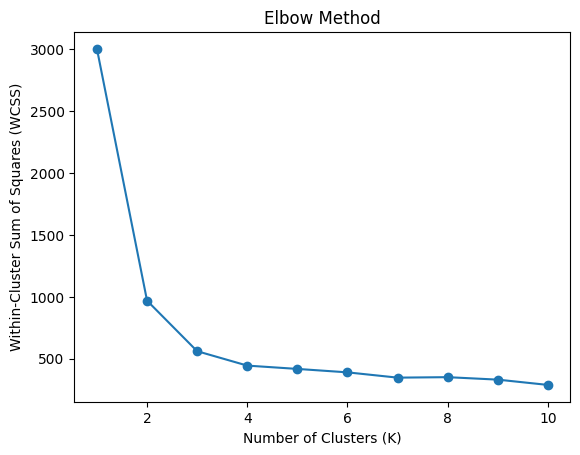

In [3]:
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt



wcss = []



for k in range(1, 11):

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)



plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Within-Cluster Sum of Squares (WCSS)')

plt.title('Elbow Method')

plt.show()

### Choosing the Number of Clusters



The elbow method shows a noticeable bend around K = 4, where the reduction

in within-cluster sum of squares begins to slow down.



This suggests that four clusters provide a good balance between compact

clusters and model simplicity.

``


In [4]:
from sklearn.cluster import KMeans



# Fit K-Means with K = 4

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)



# Add cluster labels to original dataframe

df['cluster'] = clusters



df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [5]:
# Cluster centroids in original scale

centroids = pd.DataFrame(

    kmeans.cluster_centers_,

    columns=df.drop('cluster', axis=1).columns

)



centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.157501,1.246698,-1.118685,1.171838,1.965682,1.176784
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968
3,1.107231,1.224585,-1.094820,1.333700,0.295887,1.169244


### Cluster Interpretation



- **Cluster 0** represents customers with moderate spending and average visit

  frequency, indicating steady but not highly engaged shoppers.



- **Cluster 1** consists of high‑spending and frequent visitors, representing

  the most valuable and loyal customer segment.



- **Cluster 2** includes low‑spending customers with infrequent visits, who may

  respond well to targeted promotions.



- **Cluster 3** represents customers with recent activity but lower basket

  sizes, suggesting exploratory or selective purchasing behavior.

``

In [21]:
from sklearn.decomposition import PCA



# Apply PCA to reduce to 2 components

pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_data)



# Explained variance

print("Explained variance ratio:")

print(pca.explained_variance_ratio_)



# PCA loadings

loadings = pd.DataFrame(

    pca.components_,

    columns=df.drop('cluster', axis=1).columns,

    index=['PC1', 'PC2']

)



Loadings

Explained variance ratio:
[0.83560354 0.05568764]


NameError: name 'Loadings' is not defined

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Re-run PCA from scratch (no dependencies)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# Show explained variance
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

# Show loadings clearly
loadings = pd.DataFrame(
    pca.components_,
    columns=df.drop('cluster', axis=1).columns,
    index=['PC1', 'PC2']
)
print("\nPCA Loadings:")
display(loadings)


Explained variance ratio:
[0.83560354 0.05568764]

PCA Loadings:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation



The first principal component second principal component (PC2) reflects customer engagementThe first principal component (PC1) captures overall customer value,

patterns, influenced by visit recency and category diversity.

driven primarily by spending, basket size, and visit frequency.

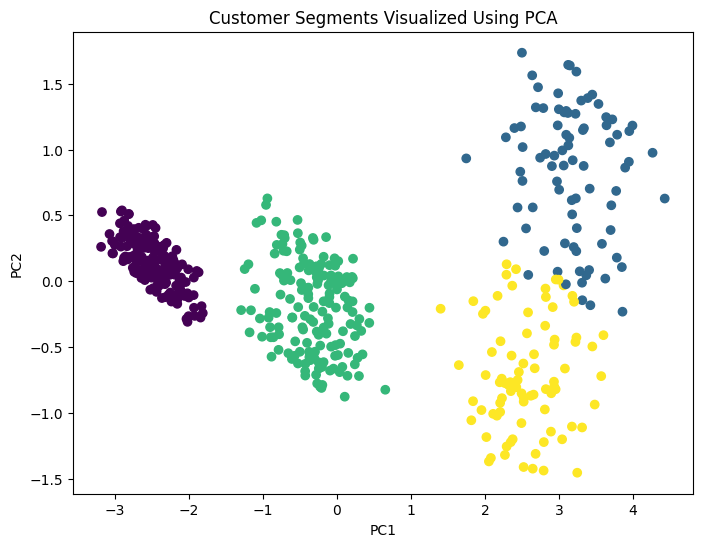

In [25]:
import matplotlib.pyplot as plt



plt.figure(figsize=(8, 6))



plt.xlabel('PC1')

plt.ylabel('PC2')

plt.title('Customer Segments Visualized Using PCA')

plt.show()

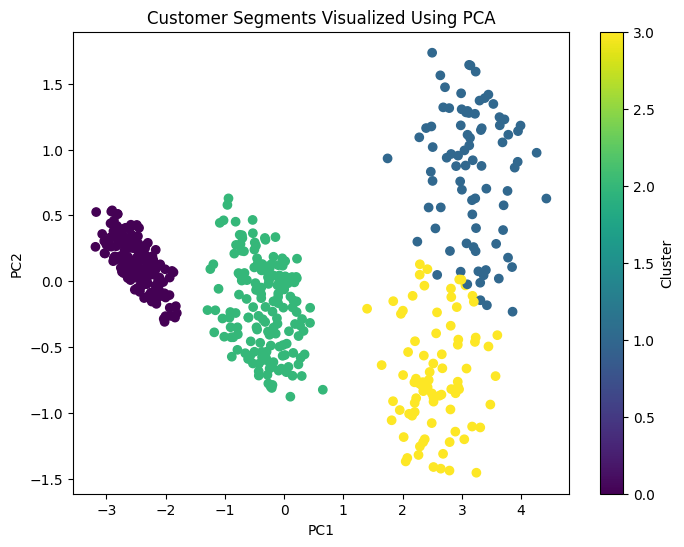

In [27]:
import matplotlib.pyplot as plt



plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=df['cluster'],
    cmap='viridis'
)

plt.xlabel('PC1')

plt.ylabel('PC2')

plt.title('Customer Segments Visualized Using PCA')

plt.colorbar(scatter, label='Cluster')

plt.show()